In [2]:
import torch
from torch.distributions import Poisson
import matplotlib.pyplot as plt

# Construct a Poisson distribution with rate 5.0 and draw 1000 samples
rate = 5.0
pois = Poisson(rate)
xs = pois.sample(sample_shape=(1000,)).numpy()

estimated_lambda=xs.mean()

True rate:       6.500
Observed mean:   6.700
Analytic MLE:    6.700
Grid-search MLE: 6.706


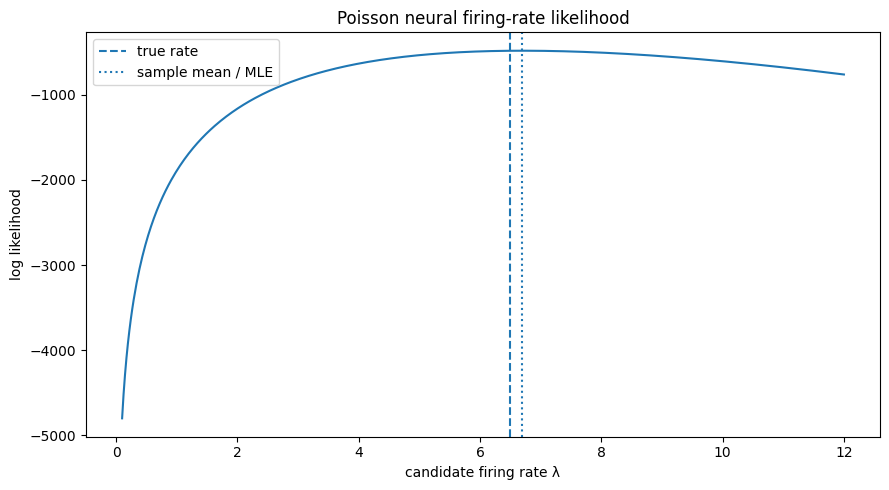

In [3]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(7)

# ------------------------------------------------------------
# SECTION 9 NEUROSYSTEMS
# Ticket BCI-001: Estimate neural firing rate
# ------------------------------------------------------------

# True rate used by our simulator.
true_rate = 6.5

# Number of equal-duration recording bins.
T = 200

# Pretend these are spike counts measured from the implant.
spikes = torch.poisson(
    torch.full((T,), true_rate, dtype=torch.float64)
)


def log_likelihood(spikes, rate):
    """
    Poisson log likelihood:

        log p(y | lambda)
          = sum_t [
                y_t log(lambda)
                - lambda
                - log(y_t!)
            ]
    """

    rate = torch.as_tensor(rate, dtype=torch.float64)

    if rate <= 0:
        return torch.tensor(-torch.inf)

    return torch.sum(
        spikes * torch.log(rate)
        - rate
        - torch.lgamma(spikes + 1)
    )


def fit_rate_mle(spikes):
    """
    Maximum-likelihood estimate for a constant
    Poisson firing rate.
    """

    return spikes.mean()


# ------------------------------------------------------------
# 1. Analytic MLE
# ------------------------------------------------------------

mle_rate = fit_rate_mle(spikes)

print(f"True rate:       {true_rate:.3f}")
print(f"Observed mean:   {spikes.mean():.3f}")
print(f"Analytic MLE:    {mle_rate:.3f}")


# ------------------------------------------------------------
# 2. Brute-force likelihood search
#
# We deliberately evaluate lots of possible rates.
# The best one should occur near the sample mean.
# ------------------------------------------------------------

candidate_rates = torch.linspace(
    0.1,
    12.0,
    500,
    dtype=torch.float64
)

log_likelihoods = torch.tensor([
    log_likelihood(spikes, rate)
    for rate in candidate_rates
])

best_index = torch.argmax(log_likelihoods)
grid_mle = candidate_rates[best_index]

print(f"Grid-search MLE: {grid_mle:.3f}")


# ------------------------------------------------------------
# 3. Plot the likelihood landscape
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    candidate_rates.numpy(),
    log_likelihoods.numpy()
)

plt.axvline(
    true_rate,
    linestyle="--",
    label="true rate"
)

plt.axvline(
    mle_rate.item(),
    linestyle=":",
    label="sample mean / MLE"
)

plt.xlabel("candidate firing rate λ")
plt.ylabel("log likelihood")
plt.title("Poisson neural firing-rate likelihood")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(7)

# ------------------------------------------------------------
# SECTION 9 NEUROSYSTEMS
# Ticket BCI-002: Bayesian neural firing-rate inference
# ------------------------------------------------------------

true_rate = 6.5

# Gamma prior parameters
# PyTorch uses concentration=shape and rate=rate
a = 3.0
b = 0.5


def simulate_spikes(T, rate):
    return torch.poisson(
        torch.full((T,), rate, dtype=torch.float64)
    )


def poisson_mle(spikes):
    return spikes.mean()


def gamma_poisson_posterior(spikes, a, b):
    """
    Prior:
        lambda ~ Gamma(a, b)

    Likelihood:
        x_t ~ Poisson(lambda)

    Posterior:
        lambda | x ~ Gamma(
            a + sum(x),
            b + T
        )
    """

    posterior_shape = a + spikes.sum()
    posterior_rate = b + len(spikes)

    return posterior_shape, posterior_rate


def gamma_map(shape, rate):
    """
    Mode of Gamma(shape, rate):

        (shape - 1) / rate

    provided shape > 1.
    """

    if shape <= 1:
        return torch.tensor(0.0)

    return (shape - 1) / rate


# ------------------------------------------------------------
# Compare different amounts of evidence
# ------------------------------------------------------------

for T in [10, 100, 10000]:

    spikes = simulate_spikes(T, true_rate)

    mle = poisson_mle(spikes)

    post_shape, post_rate = gamma_poisson_posterior(
        spikes, a, b
    )

    map_estimate = gamma_map(
        post_shape,
        post_rate
    )

    posterior_mean = post_shape / post_rate

    print("=" * 50)
    print(f"T = {T}")
    print(f"True rate       : {true_rate:.3f}")
    print(f"Sample mean/MLE : {mle:.3f}")
    print(f"Posterior MAP   : {map_estimate:.3f}")
    print(f"Posterior mean  : {posterior_mean:.3f}")

T = 10
True rate       : 6.500
Sample mean/MLE : 6.500
Posterior MAP   : 6.381
Posterior mean  : 6.476
T = 100
True rate       : 6.500
Sample mean/MLE : 7.100
Posterior MAP   : 7.085
Posterior mean  : 7.095
T = 10000
True rate       : 6.500
Sample mean/MLE : 6.525
Posterior MAP   : 6.525
Posterior mean  : 6.525


True rates:
tensor([ 3., 11.], dtype=torch.float64)

Recovered rates:
tensor([ 2.9754, 10.8073], dtype=torch.float64)

True mixing probabilities:
tensor([0.6500, 0.3500], dtype=torch.float64)

Recovered mixing probabilities:
tensor([0.6339, 0.3661], dtype=torch.float64)

Latent-state decoding accuracy: 0.956


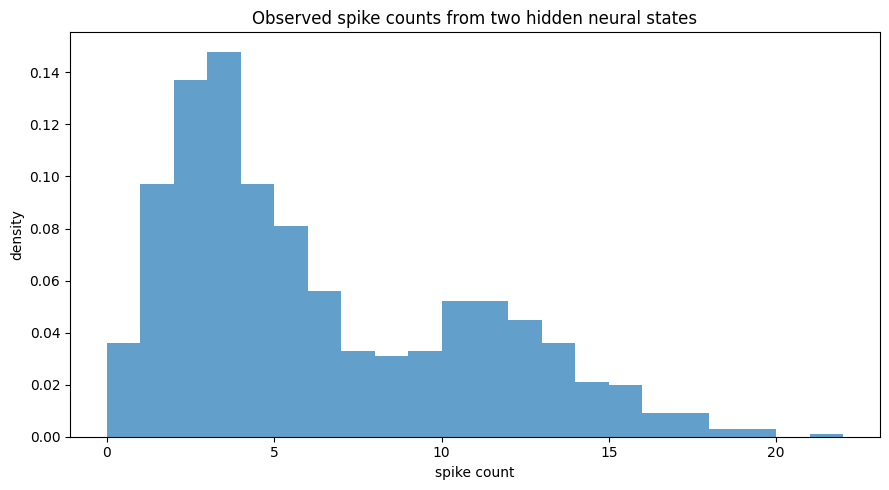

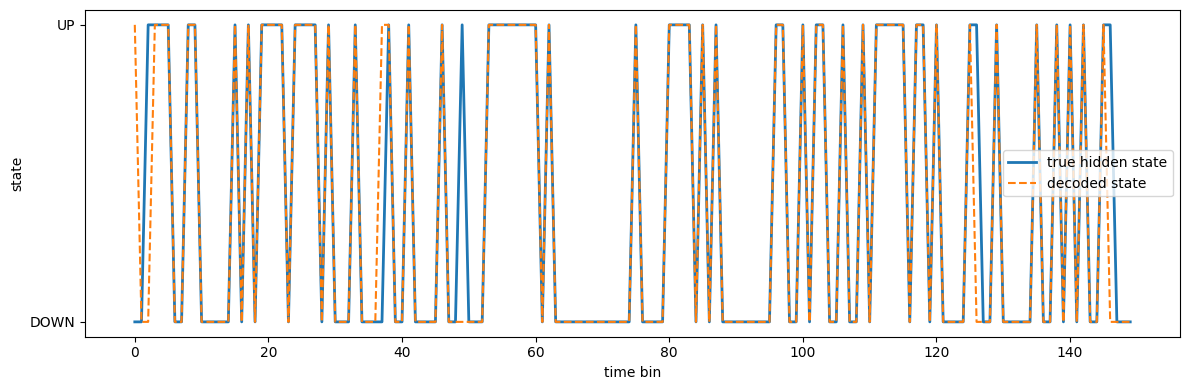

In [6]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(7)

# ------------------------------------------------------------
# SECTION 9 NEUROSYSTEMS
# Ticket BCI-003
# Two-state Poisson mixture
# ------------------------------------------------------------

T = 1000

# Ground-truth hidden model
true_pi = torch.tensor([0.65, 0.35], dtype=torch.float64)
true_rates = torch.tensor([3.0, 11.0], dtype=torch.float64)


# ------------------------------------------------------------
# 1. Generate hidden states
# ------------------------------------------------------------

z_true = torch.multinomial(
    true_pi,
    T,
    replacement=True
)

# ------------------------------------------------------------
# 2. Generate spike counts conditional on hidden state
# ------------------------------------------------------------

rates_for_each_bin = true_rates[z_true]

spikes = torch.poisson(rates_for_each_bin)


# ------------------------------------------------------------
# Poisson log probability
# ------------------------------------------------------------

def poisson_log_prob(x, rate):
    """
    log Poisson(x | rate)

    = x log(rate)
      - rate
      - log(x!)
    """

    return (
        x * torch.log(rate)
        - rate
        - torch.lgamma(x + 1)
    )


# ------------------------------------------------------------
# EM ALGORITHM
# ------------------------------------------------------------

K = 2

# Deliberately imperfect initial guesses
rates = torch.tensor([2.0, 8.0], dtype=torch.float64)

# Initial mixing probabilities
pi = torch.tensor([0.5, 0.5], dtype=torch.float64)


for iteration in range(100):

    # ========================================================
    # E STEP
    #
    # Compute:
    #
    # p(z_t = k | x_t)
    #
    # for every time bin and every hidden state.
    # ========================================================

    log_joint = torch.zeros((T, K), dtype=torch.float64)

    for k in range(K):

        log_joint[:, k] = (
            torch.log(pi[k])
            + poisson_log_prob(spikes, rates[k])
        )

    # Normalize across the two possible hidden states.
    #
    # log p(z=k | x)
    # =
    # log p(x,z=k)
    # - log sum_j p(x,z=j)

    log_norm = torch.logsumexp(
        log_joint,
        dim=1,
        keepdim=True
    )

    log_responsibilities = log_joint - log_norm

    responsibilities = torch.exp(
        log_responsibilities
    )


    # ========================================================
    # M STEP
    #
    # Re-estimate parameters using soft assignments.
    # ========================================================

    Nk = responsibilities.sum(dim=0)

    new_pi = Nk / T

    new_rates = (
        responsibilities.T @ spikes
    ) / Nk


    # Check convergence
    if torch.max(torch.abs(new_rates - rates)) < 1e-8:
        rates = new_rates
        pi = new_pi
        break

    rates = new_rates
    pi = new_pi


# ------------------------------------------------------------
# Sort states so state 0 = low rate
# ------------------------------------------------------------

order = torch.argsort(rates)

rates = rates[order]
pi = pi[order]
responsibilities = responsibilities[:, order]


# ------------------------------------------------------------
# Hard state estimate
# ------------------------------------------------------------

z_hat = torch.argmax(
    responsibilities,
    dim=1
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("True rates:")
print(true_rates)

print("\nRecovered rates:")
print(rates)

print("\nTrue mixing probabilities:")
print(true_pi)

print("\nRecovered mixing probabilities:")
print(pi)


# ------------------------------------------------------------
# Because mixture labels are arbitrary, compare after sorting
# ------------------------------------------------------------

true_low_high = torch.argsort(true_rates)

z_true_sorted = torch.zeros_like(z_true)

low_original_label = true_low_high[0]
high_original_label = true_low_high[1]

z_true_sorted[z_true == low_original_label] = 0
z_true_sorted[z_true == high_original_label] = 1

accuracy = (
    z_hat == z_true_sorted
).double().mean()

print(
    f"\nLatent-state decoding accuracy: "
    f"{accuracy:.3f}"
)


# ------------------------------------------------------------
# Visualize spike count histogram
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    spikes.numpy(),
    bins=range(
        int(spikes.max().item()) + 2
    ),
    density=True,
    alpha=0.7
)

plt.xlabel("spike count")
plt.ylabel("density")
plt.title(
    "Observed spike counts from two hidden neural states"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Visualize first 150 hidden states
# ------------------------------------------------------------

N_show = 150

plt.figure(figsize=(12, 4))

plt.plot(
    z_true_sorted[:N_show].numpy(),
    label="true hidden state",
    linewidth=2
)

plt.plot(
    z_hat[:N_show].numpy(),
    "--",
    label="decoded state"
)

plt.xlabel("time bin")
plt.ylabel("state")
plt.yticks([0, 1], ["DOWN", "UP"])
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
import torch

torch.manual_seed(7)

T = 100_000
true_rate = 6.5

spikes = torch.poisson(
    torch.full((T,), true_rate, dtype=torch.float64)
)

rate = torch.tensor(6.5, dtype=torch.float64)


def poisson_prob(x, rate):
    return (
        rate**x
        * torch.exp(-rate)
        / torch.exp(torch.lgamma(x + 1))
    )


# Compute every individual likelihood term
probs = poisson_prob(spikes, rate)

print("First 10 probabilities:")
print(probs[:10])


# BAD IDEA:
likelihood = torch.prod(probs)

print("\nFull likelihood:")
print(likelihood)

def poisson_log_prob(x, rate):
    return (
        x * torch.log(rate)
        - rate
        - torch.lgamma(x + 1)
    )


log_likelihood = torch.sum(
    poisson_log_prob(spikes, rate)
)

print("Log likelihood:")
print(log_likelihood)

First 10 probabilities:
tensor([0.0558, 0.0318, 0.0318, 0.0330, 0.1575, 0.1118, 0.1462, 0.0688, 0.0018,
        0.1454], dtype=torch.float64)

Full likelihood:
tensor(0., dtype=torch.float64)
Log likelihood:
tensor(-233843.9325, dtype=torch.float64)


Raw likelihoods:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float64)

Number equal to zero:
tensor(100)

Best rate from log likelihood:
tensor(6.4747, dtype=torch.float64)


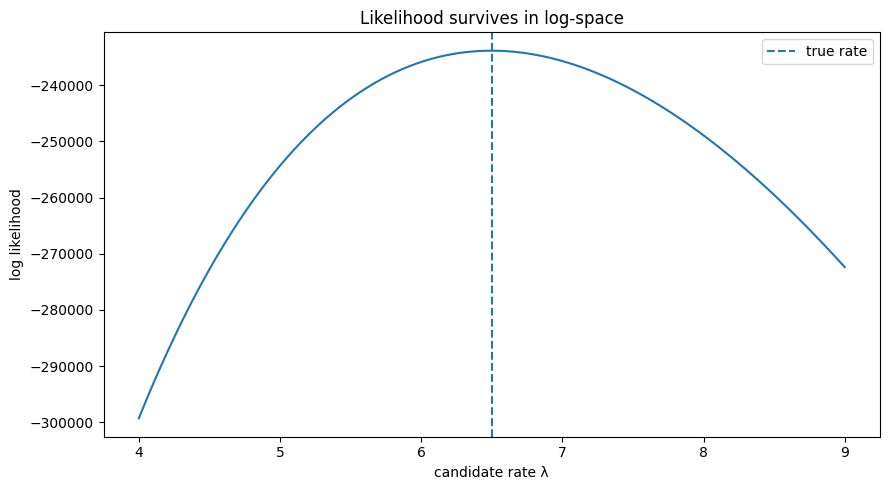

In [9]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(7)

T = 100_000
true_rate = 6.5

spikes = torch.poisson(
    torch.full((T,), true_rate, dtype=torch.float64)
)


def poisson_prob(x, rate):
    return (
        rate**x
        * torch.exp(-rate)
        / torch.exp(torch.lgamma(x + 1))
    )


def poisson_log_prob(x, rate):
    return (
        x * torch.log(rate)
        - rate
        - torch.lgamma(x + 1)
    )


candidate_rates = torch.linspace(
    4.0,
    9.0,
    100,
    dtype=torch.float64
)

likelihoods = []
log_likelihoods = []

for rate in candidate_rates:

    probs = poisson_prob(spikes, rate)

    likelihoods.append(
        torch.prod(probs)
    )

    log_likelihoods.append(
        torch.sum(
            poisson_log_prob(spikes, rate)
        )
    )


likelihoods = torch.stack(likelihoods)
log_likelihoods = torch.stack(log_likelihoods)


print("Raw likelihoods:")
print(likelihoods[:10])

print("\nNumber equal to zero:")
print((likelihoods == 0).sum())

print("\nBest rate from log likelihood:")
best_idx = torch.argmax(log_likelihoods)
print(candidate_rates[best_idx])


plt.figure(figsize=(9, 5))

plt.plot(
    candidate_rates.numpy(),
    log_likelihoods.numpy()
)

plt.axvline(
    true_rate,
    linestyle="--",
    label="true rate"
)

plt.xlabel("candidate rate λ")
plt.ylabel("log likelihood")
plt.title("Likelihood survives in log-space")
plt.legend()
plt.tight_layout()
plt.show()